In [1]:
# Preliminaries -----------------------------------------------------------
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, haven)

Loading required package: pacman



## Problem 1

Rows: 161060 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


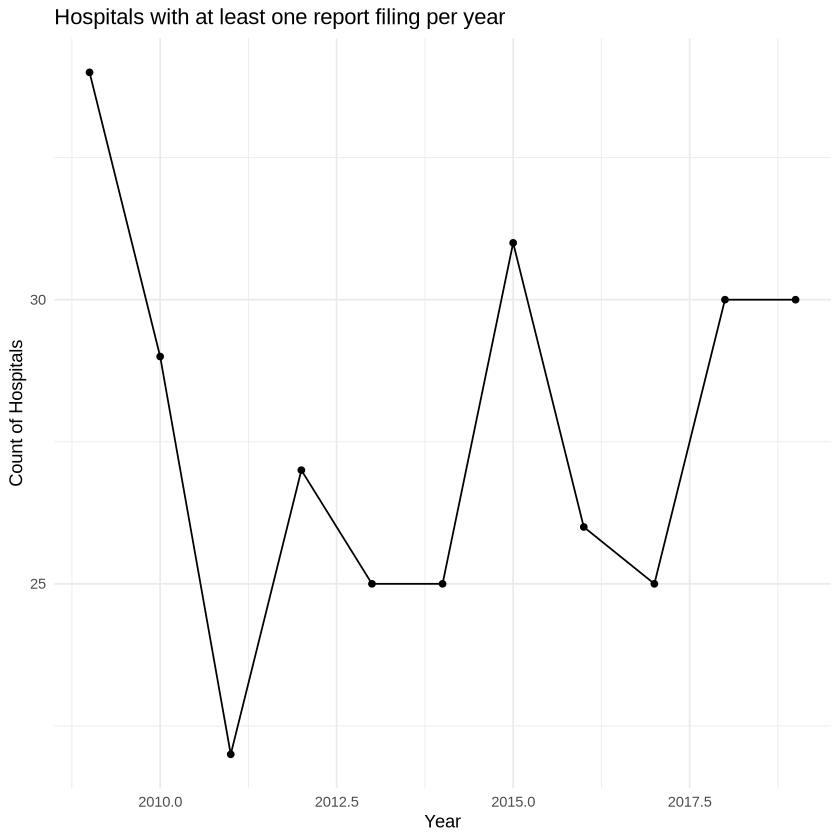

In [13]:
hcris.full <- read_tsv("../data/output/HCRIS_Data.txt")

repos_year <- hcris.full %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  filter(source == "total for year") %>%
  group_by(year) %>%
  summarise(n_hospitals = n_distinct(provider_number))

ggplot(repos_year, aes(x = year, y = n_hospitals)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Hospitals with at least one report filing per year",
    x = "Year",
    y = "Count of Hospitals"
  ) +
  theme_minimal()

## Problem 2

In [14]:
hcris.full %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  summarise(unique_num_hospitals = n_distinct(provider_number))

unique_num_hospitals
<int>
6897


## Problem 3

Warning message:
“Removed 2635 rows containing non-finite values (`stat_ydensity()`).”


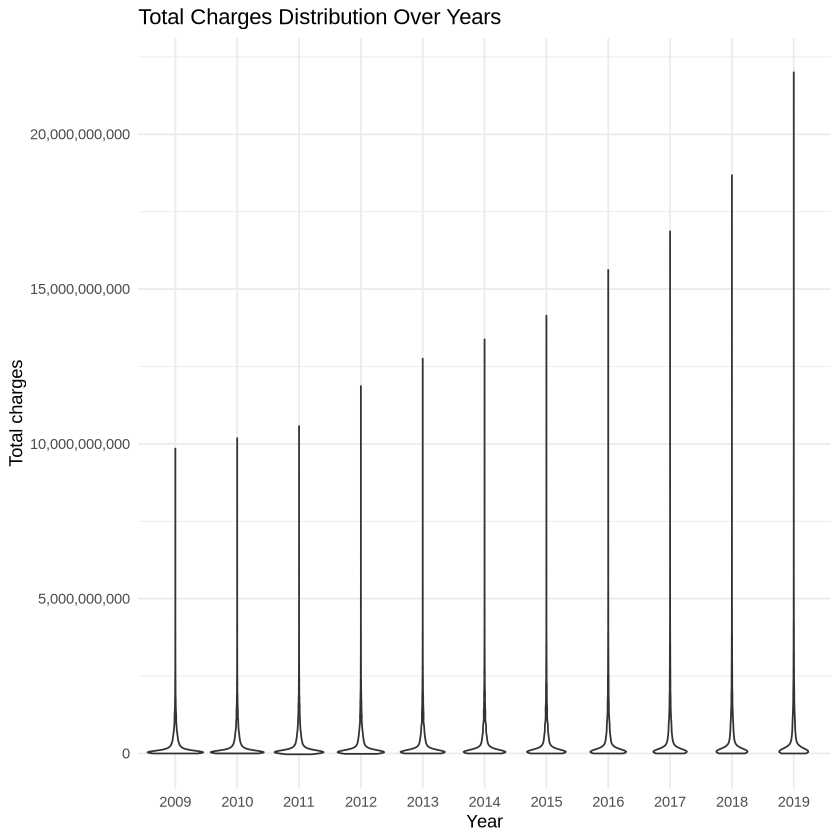

In [15]:
hcris.full %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  ggplot(aes(x = factor(year), y = tot_charges)) +
  geom_violin() +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Total Charges Distribution Over Years",
    x = "Year",
    y = "Total charges"
  ) +
  theme_minimal()

## Problem 4

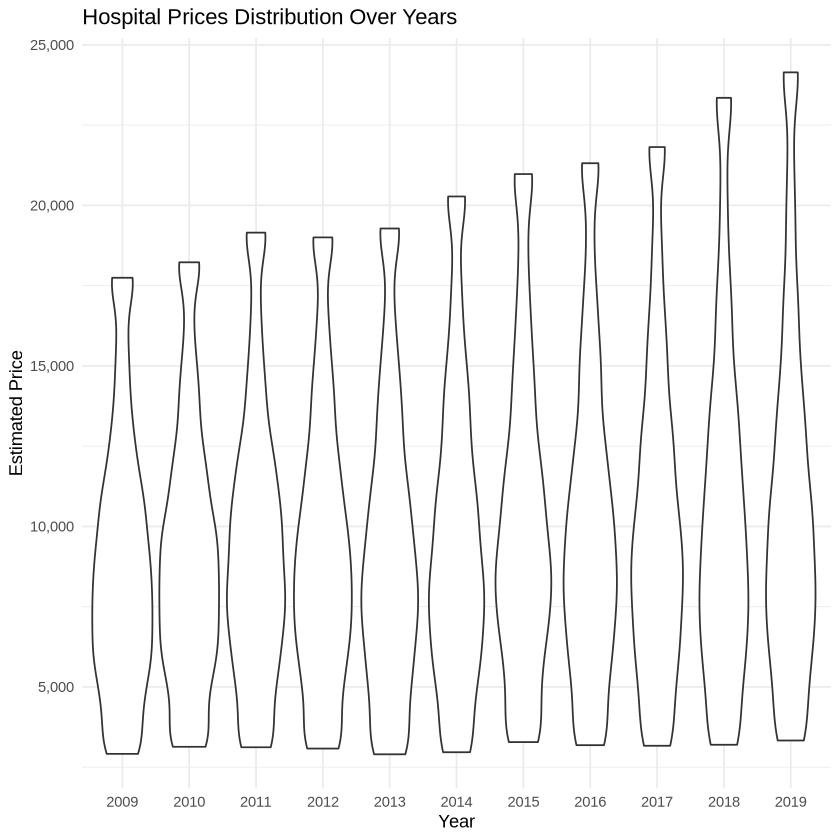

In [16]:
hcris.full %>%
  mutate(
    year = year(fy_end),
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(year >= 2009, year <= 2019) %>%
  filter(price > 0) %>%
  group_by(year) %>%
  mutate(
    p05 = quantile(price, 0.05, na.rm = TRUE),
    p95 = quantile(price, 0.95, na.rm = TRUE),
    price = pmin(pmax(price, p05), p95)
  ) %>%
  ggplot(aes(x = factor(year), y = price)) +
  geom_violin() +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Hospital Prices Distribution Over Years",
    x = "Year",
    y = "Estimated Price"
  ) +
  theme_minimal()

## Problem 5

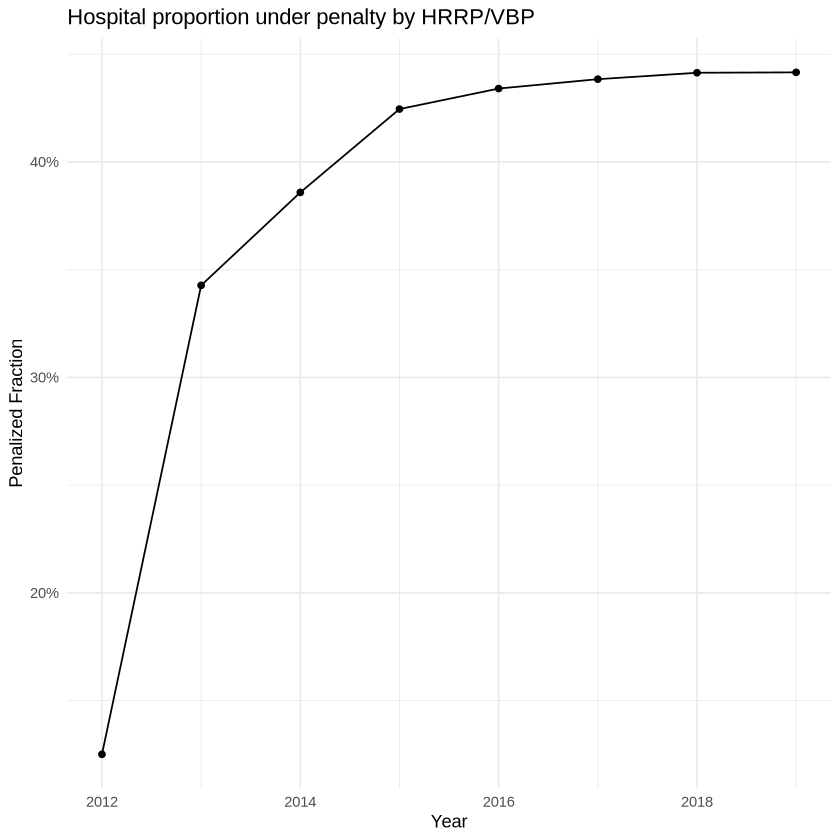

In [18]:
hcris.full %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2012, year <= 2019) %>%
  group_by(year) %>%
  summarise(
    total = n(),
    penalty = sum(hrrp_payment > 0, na.rm = TRUE),
    share_penalty = penalty/total
  ) %>%
  ggplot(aes(x = year, y = share_penalty)) +
  geom_line() +
  geom_point() +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Hospital proportion under penalty by HRRP/VBP",
    x = "Year",
    y = "Penalized Fraction"
  ) +
  theme_minimal()

# Estimate ATEs

## Problem 6

In [21]:
# price for each hospital-year
hcris.pricing <- hcris.full %>%
  mutate(
    year = year(fy_end),
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(price > 0) %>%
  group_by(year) %>%
  mutate(
    p05 = quantile(price, 0.05, na.rm = TRUE),
    p95 = quantile(price, 0.95, na.rm = TRUE),
    price = pmin(pmax(price, p05), p95)
  ) %>%
  ungroup() %>%
  select(provider_number, year, price, beds, mcare_discharges, mcaid_discharges, hrrp_payment, hvbp_payment)

# from 2011 until 2014
price.change <- hcris.pricing %>%
  filter(year %in% c(2011, 2014)) %>%
  select(provider_number, year, price) %>%
  pivot_wider(names_from = year, values_from = price, names_prefix = "price_") %>%
  mutate(price_change = price_2014 - price_2011)

# 2012 penalize
penalty.2012 <- hcris.pricing %>%
  filter(year == 2012) %>%
  mutate(net_penalty = hrrp_payment + hvbp_payment) %>%
  select(provider_number, net_penalty)

# averages before 2012 from 2009-2011
pre.2012 <- hcris.pricing %>%
  filter(year >= 2009, year <= 2011) %>%
  group_by(provider_number) %>%
  summarise(
    avg_beds = mean(beds, na.rm = TRUE),
    avg_mcare = mean(mcare_discharges, na.rm = TRUE),
    avg_mcaid = mean(mcaid_discharges, na.rm = TRUE)
  )

# combined set
hcris.combined <- price.change %>%
  inner_join(penalty.2012, by = "provider_number") %>%
  inner_join(pre.2012, by = "provider_number") %>%
  filter(!is.na(price_change))

In [22]:
ols1 <- lm(price_change ~ net_penalty, data = hcris.combined)
ols2 <- lm(price_change ~ net_penalty + avg_beds, data = hcris.combined)
ols3 <- lm(price_change ~ net_penalty + avg_beds + avg_mcaid, data = hcris.combined)

summary(ols1)
summary(ols2)
summary(ols3)


Call:
lm(formula = price_change ~ net_penalty, data = hcris.combined)

Residuals:
     Min       1Q   Median       3Q      Max 
-11503.3  -1112.1     10.4   1085.2   8514.5 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.647e+02  9.470e+01   4.906  1.2e-06 ***
net_penalty -4.873e-05  1.328e-03  -0.037    0.971    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2074 on 599 degrees of freedom
  (1863 observations deleted due to missingness)
Multiple R-squared:  2.246e-06,	Adjusted R-squared:  -0.001667 
F-statistic: 0.001346 on 1 and 599 DF,  p-value: 0.9708



Call:
lm(formula = price_change ~ net_penalty + avg_beds, data = hcris.combined)

Residuals:
     Min       1Q   Median       3Q      Max 
-11516.2  -1108.4     19.1   1082.6   8507.8 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.409e+02  9.482e+01   4.650 4.08e-06 ***
net_penalty -4.972e-05  1.323e-03  -0.038    0.970    
avg_beds     6.625e-02  2.715e-02   2.440    0.015 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2066 on 598 degrees of freedom
  (1863 observations deleted due to missingness)
Multiple R-squared:  0.009863,	Adjusted R-squared:  0.006552 
F-statistic: 2.978 on 2 and 598 DF,  p-value: 0.05163



Call:
lm(formula = price_change ~ net_penalty + avg_beds + avg_mcaid, 
    data = hcris.combined)

Residuals:
     Min       1Q   Median       3Q      Max 
-11177.3  -1132.3     30.8   1054.1   7720.2 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.462e+02  1.104e+02   1.324    0.186    
net_penalty -9.345e-04  1.310e-03  -0.713    0.476    
avg_beds     6.215e-02  2.664e-02   2.333    0.020 *  
avg_mcaid    2.114e-01  4.272e-02   4.948 9.79e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2027 on 597 degrees of freedom
  (1863 observations deleted due to missingness)
Multiple R-squared:  0.04886,	Adjusted R-squared:  0.04408 
F-statistic: 10.22 on 3 and 597 DF,  p-value: 1.426e-06


## Problem 7

Warning message:
“Removed 1863 rows containing missing values (`geom_point()`).”


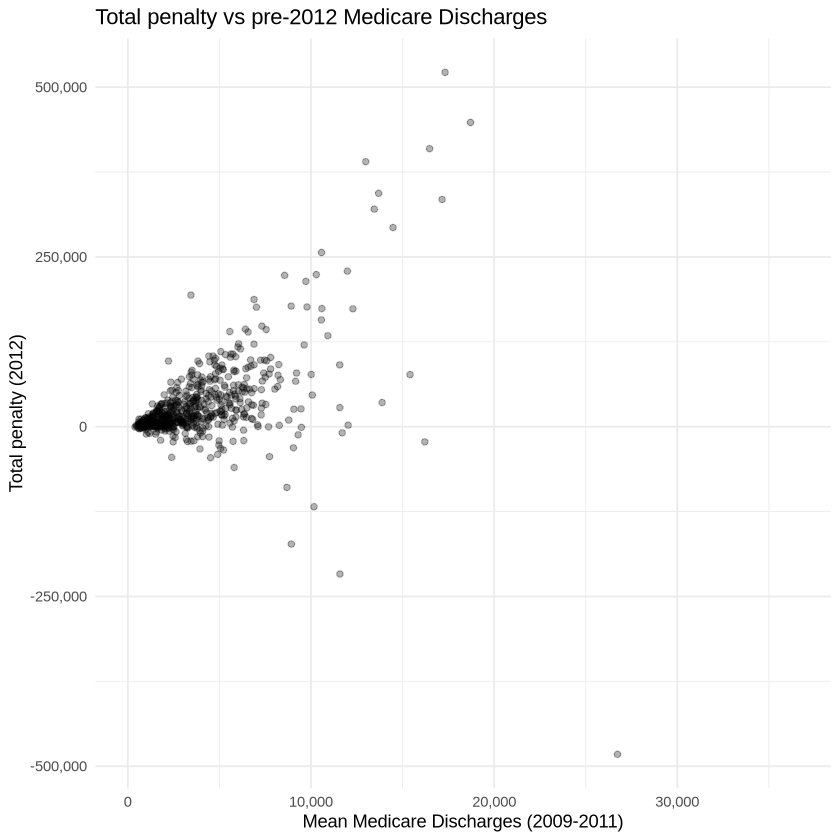

In [23]:
ggplot(hcris.combined, aes(x = avg_mcare, y = net_penalty)) +
  geom_point(alpha = 0.3) +
  scale_x_continuous(labels = scales::comma) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Total penalty vs pre-2012 Medicare Discharges",
    x = "Mean Medicare Discharges (2009-2011)",
    y = "Total penalty (2012)"
  ) +
  theme_minimal()

## Problem 8

In [24]:
library(fixest)

# first stage - net_penalty ~ avg_mcare (instrument)
fs1 <- feols(net_penalty ~ avg_mcare, data = hcris.combined)
fs2 <- feols(net_penalty ~ avg_mcare + avg_beds, data = hcris.combined)
fs3 <- feols(net_penalty ~ avg_mcare + avg_beds + avg_mcaid, data = hcris.combined)

# reduced form - price_change ~ avg_mcare (instrument)
rf1 <- feols(price_change ~ avg_mcare, data = hcris.combined)
rf2 <- feols(price_change ~ avg_mcare + avg_beds, data = hcris.combined)
rf3 <- feols(price_change ~ avg_mcare + avg_beds + avg_mcaid, data = hcris.combined)

cat("---First Stage---\n")
summary(fs1)
summary(fs2)
summary(fs3)

cat("---Reduced Form---\n")
summary(rf1)
summary(rf2)
summary(rf3)

NOTE: 1,863 observations removed because of NA values (LHS: 1,863).

NOTE: 1,863 observations removed because of NA values (LHS: 1,863).

NOTE: 1,863 observations removed because of NA values (LHS: 1,863, RHS: 10).

NOTE: 10 observations removed because of NA values (RHS: 10).



---First Stage---


OLS estimation, Dep. Var.: net_penalty
Observations: 601 
Standard-errors: IID 
               Estimate  Std. Error   t value  Pr(>|t|)    
(Intercept) -3710.16037 3810.261987 -0.973728   0.33058    
avg_mcare       9.15915    0.770799 11.882672 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 57,300.6   Adj. R2: 0.189406

OLS estimation, Dep. Var.: net_penalty
Observations: 601 
Standard-errors: IID 
                Estimate  Std. Error   t value  Pr(>|t|)    
(Intercept) -3639.135250 3814.441396 -0.954041   0.34045    
avg_mcare       9.180594    0.772149 11.889672 < 2.2e-16 ***
avg_beds       -0.431020    0.755518 -0.570497   0.56856    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 57,285.0   Adj. R2: 0.188492

OLS estimation, Dep. Var.: net_penalty
Observations: 601 
Standard-errors: IID 
                Estimate  Std. Error   t value  Pr(>|t|)    
(Intercept) -2637.363617 3842.771879 -0.686318  0.492779    
avg_mcare       9.923996    0.864663 11.477294 < 2.2e-16 ***
avg_beds       -0.417023    0.753924 -0.553136  0.580377    
avg_mcaid      -2.544288    1.343078 -1.894370  0.058659 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 57,113.6   Adj. R2: 0.19199

---Reduced Form---


OLS estimation, Dep. Var.: price_change
Observations: 2,464 
Standard-errors: IID 
              Estimate Std. Error  t value  Pr(>|t|)    
(Intercept) 200.299724  72.119549 2.777329 0.0055223 ** 
avg_mcare     0.013111   0.015037 0.871929 0.3833320    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,342.7   Adj. R2: -9.735e-5

OLS estimation, Dep. Var.: price_change
Observations: 2,464 
Standard-errors: IID 
              Estimate Std. Error  t value  Pr(>|t|)    
(Intercept) 195.625788  72.085239 2.713812 0.0066978 ** 
avg_mcare     0.009467   0.015107 0.626663 0.5309385    
avg_beds      0.070591   0.030662 2.302253 0.0214040 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,340.2   Adj. R2: 0.001646

OLS estimation, Dep. Var.: price_change
Observations: 2,454 
Standard-errors: IID 
              Estimate Std. Error  t value   Pr(>|t|)    
(Intercept) 150.910043  72.990105  2.06754 0.03878796 *  
avg_mcare    -0.023698   0.017333 -1.36719 0.17168980    
avg_beds      0.067250   0.030635  2.19524 0.02823984 *  
avg_mcaid     0.100579   0.025472  3.94856 0.00008084 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,336.8   Adj. R2: 0.007568

## Problem 9

In [25]:
# IV estimates - price_change ~ net_penalty, instrumented by avg_mcare
iv1 <- feols(price_change ~ 1 | net_penalty ~ avg_mcare, data = hcris.combined)
iv2 <- feols(price_change ~ avg_beds | net_penalty ~ avg_mcare, data = hcris.combined)
iv3 <- feols(price_change ~ avg_beds + avg_mcaid | net_penalty ~ avg_mcare, data = hcris.combined)

summary(iv1)
summary(iv2)
summary(iv3)

NOTE: 1,863 observations removed because of NA values (IV: 1,863/0).

NOTE: 1,863 observations removed because of NA values (IV: 1,863/0).

NOTE: 1,863 observations removed because of NA values (RHS: 10, IV: 1,863/0).



TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: avg_mcare
Second stage: Dep. Var.: price_change
Observations: 601 
Standard-errors: IID 
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)     277.906111  131.05855 2.12047 0.034377 *  
fit_net_penalty   0.005785    0.00309 1.87217 0.061671 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,104.1   Adj. R2: -0.033919
F-test (1st stage), net_penalty: stat = 141.2    , p < 2.2e-16 , on 1 and 599 DoF.
                     Wu-Hausman: stat =   4.57343, p = 0.032876, on 1 and 598 DoF.

TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: avg_mcare
Second stage: Dep. Var.: price_change
Observations: 601 
Standard-errors: IID 
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)     265.660531 130.578411 2.03449 0.042343 *  
fit_net_penalty   0.005426   0.003069 1.76810 0.077553 .  
avg_beds          0.066215   0.027533 2.40492 0.016479 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,090.1   Adj. R2: -0.021904
F-test (1st stage), net_penalty: stat = 141.4    , p < 2.2e-16 , on 1 and 598 DoF.
                     Wu-Hausman: stat =   4.06991, p = 0.044101, on 1 and 597 DoF.

TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: avg_mcare
Second stage: Dep. Var.: price_change
Observations: 601 
Standard-errors: IID 
                  Estimate Std. Error   t value   Pr(>|t|)    
(Intercept)     156.982520 130.931589  1.198966 2.3102e-01    
fit_net_penalty  -0.001362   0.003082 -0.442035 6.5862e-01    
avg_beds          0.062116   0.026646  2.331187 2.0075e-02 *  
avg_mcaid         0.213281   0.044495  4.793336 2.0730e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,020.0   Adj. R2: 0.043911
F-test (1st stage), net_penalty: stat = 131.7     , p < 2.2e-16 , on 1 and 597 DoF.
                     Wu-Hausman: stat =   0.023478, p = 0.878272, on 1 and 596 DoF.

## Problem 10

hi